# Phase 5: where and why the model is wrong

AUC counts wrongly ordered pairs: a positive study scored below a negative one. The reproduced model (62 windows)
gets 726 of the 8,288 pairs wrong. This notebook asks where those errors live, which studies are hard, what the
worst errors look like when read against the radiology report, and whether the probabilities mean what they say.

No images are shown. The adjudication table paraphrases report content in a line per case.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import kruskal, mannwhitneyu, spearmanr

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import ablation as ab
import evaluation as ev
import explain as ex
import plot_style as ps
import raptor_core as rc
import reports as rp

ps.apply()
RUN = ROOT / "outputs/kaggle/gold_run"
FIG = ROOT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)

gold = pd.read_csv(RUN / "gold_labels.csv")
Y = gold[rc.LAB].values.astype(int)
model, _ = rc.load_checkpoint(str(ROOT / "models/raptor_ft_coatnet_v10_full.pt"), "cpu")
logits, attn, wlogits = ex.head_outputs(model, np.load(RUN / "feats_A_imagenet.npy"))
probs = ab.sigmoid(logits)
N, F = Y.shape

## 1. How concentrated are the errors?

Every wrong pair involves one positive and one negative study. Charge each study-finding cell with the wrong
pairs it takes part in: a positive scored below many negatives, or a negative scored above many positives.

726 wrong pairs over 696 study-finding cells
  25% of them come from 17 cells (2.4%)
  50% of them come from 51 cells (7.3%)
  75% of them come from 118 cells (17.0%)


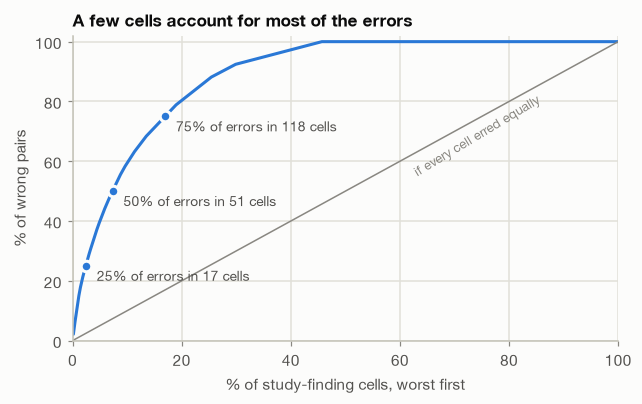

In [2]:
wrong = np.zeros((N, F))
for j in range(F):
    pos = Y[:, j] == 1
    miss = 1 - ev.psi(probs[pos, j], probs[~pos, j])          # [positives, negatives]
    wrong[pos, j], wrong[~pos, j] = miss.sum(1), miss.sum(0)
total = wrong.sum() / 2
share = np.sort(wrong.ravel() / 2)[::-1].cumsum() / total
cells_for = {q: int(np.searchsorted(share, q)) + 1 for q in (0.25, 0.5, 0.75)}
print(f"{total:.0f} wrong pairs over {N * F} study-finding cells")
for q, n in cells_for.items():
    print(f"  {q:.0%} of them come from {n} cells ({n / (N * F):.1%})")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(1, N * F + 1) / (N * F) * 100
ax.plot(x, share * 100, color=ps.BLUE)
ax.plot([0, 100], [0, 100], color=ps.MUTED, lw=1)
ax.text(62, 55, "if every cell erred equally", color=ps.MUTED, fontsize=8.5, rotation=31)
for q, n in cells_for.items():
    ax.scatter(n / (N * F) * 100, q * 100, s=48, color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=2, zorder=3)
    ax.text(n / (N * F) * 100 + 2, q * 100 - 5, f"{q:.0%} of errors in {n} cells", fontsize=9, color=ps.INK_2)
ax.set_xlabel("% of study-finding cells, worst first")
ax.set_ylabel("% of wrong pairs")
ax.set_xlim(0, 100); ax.set_ylim(0, 102)
ax.set_title("A few cells account for most of the errors")
fig.savefig(FIG / "phase5_concentration.png")
plt.show()

A quarter of all wrong pairs come from 17 of the 696 cells, and half from 51. AUC errors are not a thin spread
of near-misses: they are dominated by a few confident mistakes, which makes reading those cases worthwhile.

## 2. Which studies are hard?

Give each study a difficulty score: the average, over its 12 findings, of the fraction of opposite-label studies it
is misordered with. Then compare against what we know about each study: the report language (a stand-in for the
hospital), scanner vendor and field strength, whether a series slot was empty, whether any series was magnified by
the 140 mm crop, and how many findings the knee has.

In [3]:
import json

pairs_per_cell = np.where(Y == 1, (Y == 0).sum(0), (Y == 1).sum(0))
difficulty = (wrong / pairs_per_cell).mean(1)
masks = np.load(RUN / "gold_masks_A.npy")
slots = json.load(open(RUN / "gold_slots.json"))["A"]
meta = pd.read_csv(RUN / "gold_series_meta.csv").set_index("SeriesInstanceUID")
rows = []
for i, sid in enumerate(gold.StudyInstanceUID):
    used = [s for s in slots[sid] if s["series"]]
    fov = min(min(meta.loc[s["series"], ["Rows", "Columns"]]) * s["pixel_spacing"] for s in used)
    first = meta[meta.StudyInstanceUID == sid].iloc[0]
    rows.append({"difficulty": difficulty[i], "language": rp.LANG_NAMES[rp.detect_language(gold.Report[i])],
                 "vendor": str(first.Manufacturer).split()[0].upper(), "tesla": first.MagneticFieldStrength,
                 "empty slot": masks[i].sum() < 64, "magnified series": fov < 140, "positive findings": Y[i].sum()})
studies = pd.DataFrame(rows)
studies.groupby("language").difficulty.agg(["count", "mean"]).sort_values("count", ascending=False)

,count,mean
language,,
English,28,0.076
Spanish,10,0.086
Turkish,6,0.076
Croatian,4,0.076
Bulgarian,3,0.101
Greek,3,0.097
Dutch,2,0.062
German,2,0.175


In [4]:
tests = {
    "language (groups of 3+)": kruskal(*[g.difficulty for _, g in studies.groupby("language") if len(g) >= 3]).pvalue,
    "vendor (groups of 3+)": kruskal(*[g.difficulty for _, g in studies.groupby("vendor") if len(g) >= 3]).pvalue,
    "3 T vs 1.5 T": mannwhitneyu(studies[studies.tesla == 3].difficulty, studies[studies.tesla == 1.5].difficulty).pvalue,
    "empty slot vs not": mannwhitneyu(*[studies[studies["empty slot"] == v].difficulty for v in (True, False)]).pvalue,
    "magnified series vs not": mannwhitneyu(*[studies[studies["magnified series"] == v].difficulty for v in (True, False)]).pvalue,
    "number of positive findings (Spearman)": spearmanr(studies["positive findings"], studies.difficulty).pvalue,
}
pd.Series(tests, name="p-value").round(3).to_frame()

,p-value
language (groups of 3+),0.647
vendor (groups of 3+),0.551
3 T vs 1.5 T,0.179
empty slot vs not,0.910
magnified series vs not,0.750
number of positive findings (Spearman),0.050


Nothing about where or how a study was acquired predicts difficulty on these 58 studies. The one borderline signal
is the number of positive findings (Spearman +0.26, p = 0.05): multi-injury knees are harder. With groups this small
(two German studies, three Greek) only a large effect could show, so "no evidence" is the honest reading, not "no
effect".

The reports themselves are in eight languages here and nine across the full training set (English, Spanish,
Turkish, Croatian, Greek, German, Bulgarian, Dutch, French), so the language model that produced the training labels
had to read all of them.

## 3. Findings the model cannot tell apart

If the model scored each finding from its own evidence, two findings' scores would be about as correlated as
their labels. Compare the two correlations for all 66 pairs of findings.

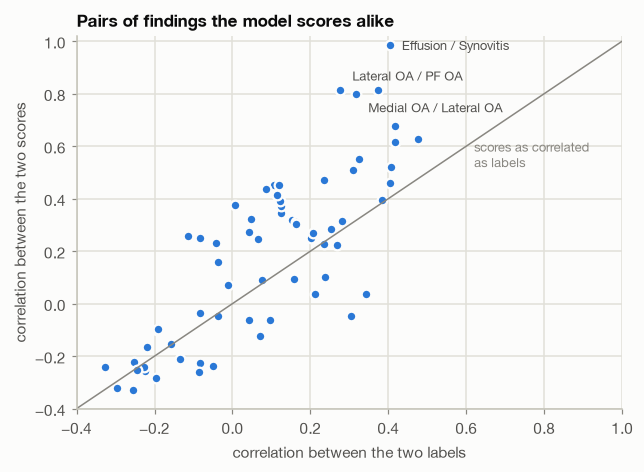

,finding a,finding b,label correlation,score correlation,excess
56,Effusion,Synovitis,0.403,0.984,0.581
45,Lateral OA,PF OA,0.276,0.815,0.539
38,Medial OA,Lateral OA,0.317,0.799,0.482
39,Medial OA,PF OA,0.374,0.812,0.438
17,MCL,Synovitis,-0.114,0.258,0.371
23,Medial Meniscus,Lateral OA,0.006,0.377,0.371


In [5]:
iu = np.triu_indices(F, 1)
label_r, score_r = np.corrcoef(Y.T)[iu], np.corrcoef(logits.T)[iu]
corr = pd.DataFrame({"finding a": np.array(rc.LAB)[iu[0]], "finding b": np.array(rc.LAB)[iu[1]],
                     "label correlation": label_r, "score correlation": score_r})
corr["excess"] = corr["score correlation"] - corr["label correlation"]

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(corr["label correlation"], corr["score correlation"], s=40, color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=1.5)
ax.plot([-0.4, 1], [-0.4, 1], color=ps.MUTED, lw=1)
ax.text(0.62, 0.52, "scores as correlated\nas labels", fontsize=8.5, color=ps.MUTED)
for (_, r), dy in zip(corr.sort_values("excess", ascending=False).head(3).iterrows(), [-3, 6, -12]):
    ax.annotate(f"{r['finding a']} / {r['finding b']}", (r["label correlation"], r["score correlation"]),
                xytext=(8, dy), textcoords="offset points", fontsize=8.5, color=ps.INK_2)
ax.set_xlabel("correlation between the two labels")
ax.set_ylabel("correlation between the two scores")
ax.set_xlim(-0.4, 1); ax.set_ylim(-0.4, 1.02)
ax.set_title("Pairs of findings the model scores alike")
fig.savefig(FIG / "phase5_entangled.png")
plt.show()
corr.sort_values("excess", ascending=False).head(6)

Effusion and synovitis are the extreme: their scores correlate at 0.98 across studies while their labels correlate
at 0.40. The three osteoarthritis compartments follow (score correlations about 0.8, label correlations about 0.3).

Does each score still carry its own information? Rank each finding's studies with a *sibling's* score and compare.

In [6]:
ix = rc.LAB.index
oa = [ix("Medial OA"), ix("Lateral OA"), ix("PF OA")]
rows = [{"finding": "Synovitis", "own score": ev.auc(Y[:, ix("Synovitis")], logits[:, ix("Synovitis")]),
         "sibling score": ev.auc(Y[:, ix("Synovitis")], logits[:, ix("Effusion")]), "sibling": "Effusion"}]
for j in oa:
    k = max((k for k in oa if k != j), key=lambda k: ev.auc(Y[:, j], logits[:, k]))
    rows.append({"finding": rc.LAB[j], "own score": ev.auc(Y[:, j], logits[:, j]),
                 "sibling score": ev.auc(Y[:, j], logits[:, k]), "sibling": rc.LAB[k]})
siblings = pd.DataFrame(rows).set_index("finding")
siblings["own minus sibling"] = siblings["own score"] - siblings["sibling score"]
effusion_pos = Y[:, ix("Effusion")] == 1
print("synovitis AUC within the %d effusion-positive studies: own score %.3f, effusion score %.3f" % (
    effusion_pos.sum(), ev.auc(Y[effusion_pos, ix("Synovitis")], logits[effusion_pos, ix("Synovitis")]),
    ev.auc(Y[effusion_pos, ix("Synovitis")], logits[effusion_pos, ix("Effusion")])))
siblings

synovitis AUC within the 35 effusion-positive studies: own score 0.678, effusion score 0.650


,own score,sibling score,sibling,own minus sibling
finding,,,,
Synovitis,0.805,0.800,Effusion,0.005
Medial OA,0.963,0.864,Lateral OA,0.099
Lateral OA,0.870,0.799,PF OA,0.072
PF OA,0.830,0.727,Lateral OA,0.103


- **Synovitis is effusion under another name.** Ranking studies for synovitis by the *effusion* score gives 0.800,
  against 0.805 for the synovitis score itself. Even among effusion-positive knees the synovitis score barely
  separates synovitis (0.68 against 0.65). This is the model's weakest finding, and the reason.
- **The OA compartments are tangled but not merged.** Each compartment's own score still beats the best other
  compartment by 0.07-0.10, so compartment-specific evidence exists. It is diluted by a shared "degenerative knee"
  component.

Section 6 checks the training labels and finds where each of these comes from.

There is a clinical reason the synovitis result is unsurprising. Without intravenous contrast, synovial thickening
and joint fluid look alike on MRI, and scoring systems for non-contrast knee MRI grade them together as
"effusion-synovitis". Training labels read from reports would inherit whatever each radiologist chose to call it.

## 4. The worst errors, read against the reports

The 14 cells with the most wrong pairs, each read in its original language (English, Spanish, Bulgarian, Greek,
Dutch) and put in one of five categories. The labels are the competition's structured labels. They may come from a
separate expert reading rather than from these reports, so "label and report disagree" says the two sources
conflict, not which one is right.

In [7]:
ADJUDICATION = {
    (47, "PF OA"): ("focal or early cartilage damage labelled OA",
                    "grade 3-4 chondromalacia of the trochlea, in an acutely injured knee (ACL tear, bone contusion)"),
    (49, "PF OA"): ("label and report disagree",
                    "patella and patellar cartilage described as unremarkable; the cartilage damage is on the medial femoral condyle"),
    (28, "PF OA"): ("focal or early cartilage damage labelled OA",
                    "thinning of medial compartment and medial patellar facet cartilage, called incipient osteoarthritis, beside ACL and MCL tears"),
    (42, "Synovitis"): ("effusion scored as synovitis",
                        "large joint effusion in a severe multi-fracture injury; synovitis not mentioned"),
    (40, "Lateral Meniscus"): ("label and report disagree",
                               "menisci described as normal; ACL rupture, MCL sprain and impaction fracture"),
    (14, "Fracture"): ("subtle finding missed",
                       "undisplaced fracture of the tibial intercondylar eminence with marrow oedema"),
    (11, "Synovitis"): ("effusion scored as synovitis",
                        "ACL, MCL and both menisci torn, effusion, bone contusions; synovitis not mentioned"),
    (47, "Synovitis"): ("label and report disagree",
                        "synovial hypertrophy indicative of synovitis, repeated in the impression"),
    (50, "Lateral OA"): ("label and report disagree",
                         "cartilage described as normal; patellar dislocation pattern (medial patellofemoral ligament tear)"),
    (10, "Synovitis"): ("mild or borderline finding",
                        "Hoffa fat-pad impingement and iliotibial band friction; no effusion described"),
    (53, "Synovitis"): ("effusion scored as synovitis",
                        "ACL tear with mild to moderate effusion; synovitis not mentioned"),
    (17, "Synovitis"): ("mild or borderline finding",
                        "mild effusion with slight diffuse synovitis"),
    (0, "PF OA"): ("focal or early cartilage damage labelled OA",
                   "a single thin focal chondral ulcer on the trochlea; patellar cartilage normal"),
    (6, "Lateral OA"): ("focal or early cartilage damage labelled OA",
                        "6 x 5 mm full-thickness chondral ulcer on the lateral femoral condyle after acute trauma"),
}
worst = sorted(((wrong[i, j], i, rc.LAB[j]) for i in range(N) for j in range(F)), reverse=True)[:14]
assert {(i, f) for _, i, f in worst} == set(ADJUDICATION), "the worst cells changed; re-read the reports"
cases = pd.DataFrame([{"study": i, "finding": f, "label": Y[i, ix(f)], "p": probs[i, ix(f)], "wrong pairs": w,
                       "language": rp.LANG_NAMES[rp.detect_language(gold.Report[i])],
                       "category": ADJUDICATION[(i, f)][0], "report says": ADJUDICATION[(i, f)][1]}
                      for w, i, f in worst])
cases

,study,finding,label,p,wrong pairs,language,category,report says
0,47,PF OA,1,0.103,31.0,English,focal or early cartilage damage labelled OA,"grade 3-4 chondromalacia of the trochlea, in a..."
1,49,PF OA,1,0.107,30.0,Bulgarian,label and report disagree,patella and patellar cartilage described as un...
2,28,PF OA,1,0.112,28.0,Greek,focal or early cartilage damage labelled OA,thinning of medial compartment and medial pate...
3,42,Synovitis,0,0.805,26.0,English,effusion scored as synovitis,large joint effusion in a severe multi-fractur...
4,40,Lateral Meniscus,1,0.337,26.0,Dutch,label and report disagree,"menisci described as normal; ACL rupture, MCL ..."
5,14,Fracture,1,0.426,26.0,Bulgarian,subtle finding missed,undisplaced fracture of the tibial intercondyl...
6,11,Synovitis,0,0.828,26.0,Spanish,effusion scored as synovitis,"ACL, MCL and both menisci torn, effusion, bone..."
7,47,Synovitis,0,0.796,25.0,English,label and report disagree,"synovial hypertrophy indicative of synovitis, ..."
8,50,Lateral OA,1,0.357,21.0,English,label and report disagree,cartilage described as normal; patellar disloc...
9,10,Synovitis,1,0.447,20.0,Spanish,mild or borderline finding,Hoffa fat-pad impingement and iliotibial band ...


In [8]:
summary = cases.groupby("category").agg(cells=("finding", "size"), wrong_pairs=("wrong pairs", "sum"))
summary["share of all wrong pairs"] = summary.wrong_pairs / total
summary.sort_values("wrong_pairs", ascending=False)

,cells,wrong_pairs,share of all wrong pairs
category,,,
label and report disagree,4,102.0,0.140
focal or early cartilage damage labelled OA,4,90.0,0.124
effusion scored as synovitis,3,69.0,0.095
mild or borderline finding,2,37.0,0.051
subtle finding missed,1,26.0,0.036


**Reading it.**

- **Only one of the 14 is a clear model miss**: an undisplaced tibial eminence fracture, a genuinely subtle finding.
- **In four, the label and the report disagree, and the model sides with the report every time.** Two positives
  (lateral meniscus, lateral OA) whose reports call the structure normal, one PF OA positive whose report puts the
  cartilage damage in the medial compartment instead, and one synovitis negative whose report states synovitis.
- **Four are focal cartilage lesions labelled as osteoarthritis**, mostly in acutely injured knees: a single chondral
  ulcer, grade 3-4 chondromalacia of the trochlea. The model has learned OA as a diffuse degenerative pattern, and a
  6 mm ulcer in a young trauma knee does not look like that.
- **Three are effusion scored as synovitis**, in trauma knees with effusion and no synovitis in the report. This is
  Section 3's entanglement seen case by case.
- **Two are mild or borderline synovitis** that the model scored in the middle.

So most of the worst errors sit on boundaries the labels themselves draw inconsistently (focal damage against OA,
fluid against synovitis) or where label and report conflict. Before blaming the model for its 0.80 on synovitis,
note that "synovitis" is not one consistent thing in these labels.

## 5. Do the probabilities mean anything?

In [9]:
def reliability(p, y, bins=10):
    idx = np.minimum((p * bins).astype(int), bins - 1)
    return pd.DataFrame([{"mean predicted": p[idx == b].mean(), "observed rate": y[idx == b].mean(), "n": (idx == b).sum()}
                         for b in range(bins) if (idx == b).any()])


def ece(p, y, bins=10):
    r = reliability(p, y, bins)
    return float((r.n * (r["mean predicted"] - r["observed rate"]).abs()).sum() / r.n.sum())


pd.DataFrame({"mean predicted": probs.mean(0), "prevalence": Y.mean(0)}, index=rc.LAB).T

,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
mean predicted,0.630,0.528,0.528,0.610,0.435,0.491,0.404,0.653,0.603,0.397,0.667,0.559
prevalence,0.414,0.155,0.448,0.397,0.259,0.190,0.362,0.603,0.466,0.207,0.328,0.310


Every finding's average prediction is above its prevalence, badly so for the rarer ones (MCL 0.53 against 0.16).

Two training choices distort the probabilities, each in its own way:

- **Positive weighting shifts the logits up.** The loss is `BCEWithLogitsLoss(pos_weight=w)` with
  $w = (1 - \text{prevalence}) / \text{prevalence}$, clipped to 1-10. Weighting the positive term by $w$ moves the
  loss minimum from the true odds to $w$ times the odds, so every logit comes out too high by $\log w$, most for the
  rarest findings.
- **Soft labels squeeze the logits towards zero.** A report that hedges becomes a target of 0.8 rather than 1, so the
  model is taught never to be fully sure and its logits come out compressed.

The matching repairs are an offset per finding, and a slope stretching all logits. Test both, fitting on 57 studies
and applying to the one left out so the result is honest on 58.

In [10]:
def nll_of(p, y):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()


def fit(idx, shared_slope):
    """Per-finding offsets, plus one slope shared by all findings if shared_slope, fitted on studies idx."""
    def loss(params):
        slope = params[0] if shared_slope else 1.0
        return nll_of(ab.sigmoid(slope * logits[idx] + params[-F:]), Y[idx])
    x0 = np.r_[1.0, np.zeros(F)] if shared_slope else np.zeros(F)
    x = minimize(loss, x0).x
    return (x[0] if shared_slope else 1.0), x[-F:]


versions = {"as trained": probs}
for name, shared in [("offset per finding", False), ("offset per finding + shared slope", True)]:
    out = np.zeros_like(probs)
    for i in range(N):
        slope, offsets = fit(np.arange(N) != i, shared)
        out[i] = ab.sigmoid(slope * logits[i] + offsets)
    versions[name] = out

calib = pd.DataFrame({name: {"Brier": ((P - Y) ** 2).mean(), "log loss": nll_of(P, Y), "ECE": ece(P.ravel(), Y.ravel()),
                             "macro-AUC": rc.macro_auc(Y, P)[0]} for name, P in versions.items()}).T
slope_all, offsets_all = fit(np.arange(N), True)
_, shifts = fit(np.arange(N), False)
print(f"shared slope fitted on all 58 studies: {slope_all:.2f}")
print(pd.DataFrame({"offset alone": shifts, "weight it implies, exp(-offset)": np.exp(-shifts)}, index=rc.LAB).T.round(2).to_string())
calib

shared slope fitted on all 58 studies: 1.77
                                  ACL   MCL  Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  Synovitis  Baker's  Contusion  Fracture
offset alone                    -1.71 -2.20            -0.45             -1.17      -1.33       -2.15  -0.27     -0.30      -0.61    -1.54      -1.74     -1.22
weight it implies, exp(-offset)  5.52  9.01             1.57              3.23       3.78        8.56   1.32      1.34       1.84     4.65       5.72      3.37


,Brier,log loss,ECE,macro-AUC
as trained,0.164,0.501,0.197,0.917
offset per finding,0.114,0.372,0.077,0.903
offset per finding + shared slope,0.107,0.348,0.026,0.903


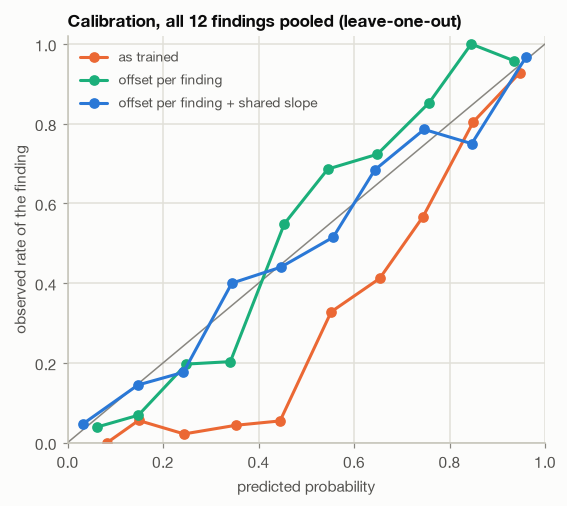

In [11]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.plot([0, 1], [0, 1], color=ps.MUTED, lw=1)
for (name, P), colour in zip(versions.items(), [ps.ORANGE, ps.AQUA, ps.BLUE]):
    r = reliability(P.ravel(), Y.ravel())
    ax.plot(r["mean predicted"], r["observed rate"], color=colour, marker="o", markersize=6, label=name)
ax.set_xlabel("predicted probability")
ax.set_ylabel("observed rate of the finding")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_title("Calibration, all 12 findings pooled (leave-one-out)")
ax.legend(loc="upper left", fontsize=9)
fig.savefig(FIG / "phase5_calibration.png")
plt.show()

**Reading it.**

- **As trained, a mid-range probability means almost nothing.** Predictions between 0.2 and 0.5 turn out positive
  2-5% of the time. Calibration error (ECE) is 0.20.
- **An offset per finding fixes the level but overshoots.** ECE falls to 0.08, but the curve now sits above the
  diagonal from about 0.45 up. The offsets behave as the weighting explanation predicts: the rarest findings need the
  largest (MCL and lateral OA -2.2, implied weights about 9), and common ones need little (effusion and PF OA -0.3).
- **Adding one shared slope fixes the shape.** The fitted slope is 1.77: the logits were compressed, as soft labels
  predict. With 13 parameters in all, ECE falls to 0.026, Brier score from 0.164 to 0.107 and log loss from 0.50 to 0.35,
  and the curve stays close to the diagonal.
- **Macro-AUC reads 0.903 after recalibration rather than 0.917.** An offset and a positive slope cannot change a
  ranking, but each left-out study gets slightly different parameters, and on 58 studies that jitter reorders a few
  close pairs. Parameters fitted once on separate data would leave the AUC untouched.

For the competition none of this matters: the metric is AUC, and the author's inference notebook converts scores to
ranks anyway. For anyone reading the outputs as probabilities of disease, it matters a great deal.

## 6. Checking the explanations against the training labels

Sections 3 and 5 blamed three things on how the model was trained: synovitis tracking effusion, logits squeezed
towards zero, and probabilities shifted up by positive weighting. The author published the language-model soft
labels the checkpoint was trained on (`dreaddevelopment/rsna-knee-labels`, CC0), one row per non-gold study, so
each explanation can be tested directly. Download the CSV to `data/soft_labels/` to run this section.

In [12]:
soft_path = ROOT / "data/soft_labels/labels_llm_soft.csv"
soft = pd.read_csv(soft_path)
S = soft[rc.LAB].values
print(f"{len(soft)} training studies with soft labels; overlap with the 58 gold studies: "
      f"{len(set(soft.StudyInstanceUID.astype(str)) & set(gold.StudyInstanceUID.astype(str)))}")
levels = pd.Series(S.round(2).ravel()).value_counts().sort_index()
levels.to_frame("count").T

4349 training studies with soft labels; overlap with the 58 gold studies: 0


,0.05,0.07,0.08,0.10,0.15,0.20,0.30,0.35,0.45,0.76,0.80,0.82,0.85,0.95
count,24273,946,1176,3149,1766,6191,197,3157,1599,608,4382,123,1296,3325


### 6a. Why the logits are squeezed

The targets take 14 values, never below 0.05 and never above 0.95. A model trained to hit 0.95 learns to stop at a
logit of $\log(0.95/0.05) \approx 2.9$. On gold labels that really are 0 or 1 its logits then need stretching, which is
the slope of 1.77 found in Section 5.

### 6b. Inherited or learned?

In [13]:
def pair_corr(M, a, b):
    return np.corrcoef(M[:, ix(a)], M[:, ix(b)])[0, 1]


inherit = pd.DataFrame([{"pair": f"{a} / {b}",
                         "training soft labels": pair_corr(S, a, b),
                         "gold labels": pair_corr(Y, a, b),
                         "model scores": pair_corr(logits, a, b)}
                        for a, b in [("Effusion", "Synovitis"), ("Medial OA", "Lateral OA"),
                                     ("Lateral OA", "PF OA"), ("Medial OA", "PF OA")]]).set_index("pair")
inherit

,training soft labels,gold labels,model scores
pair,,,
Effusion / Synovitis,0.880,0.403,0.984
Medial OA / Lateral OA,0.390,0.317,0.799
Lateral OA / PF OA,0.363,0.276,0.815
Medial OA / PF OA,0.415,0.374,0.812


In [14]:
eff_level = pd.cut(S[:, ix("Effusion")], [0, 0.3, 1.0], labels=["effusion low (0.05-0.2)", "effusion high (0.76-0.95)"])
syn_level = pd.cut(S[:, ix("Synovitis")], [0, 0.1, 0.3, 0.6, 1.0],
                   labels=["0.05-0.1", "0.15-0.2", "0.35-0.45 (unsure)", "0.76-0.95"])
pd.crosstab(eff_level, syn_level, rownames=["training label"], colnames=["synovitis soft label"])

synovitis soft label,0.05-0.1,0.15-0.2,0.35-0.45 (unsure),0.76-0.95
training label,,,,
effusion low (0.05-0.2),60,120,3020,37
effusion high (0.76-0.95),7,77,0,1028


- **The synovitis entanglement was in the labels.** In the training labels effusion and synovitis correlate at 0.88,
  against 0.40 in the radiologists' gold labels. When a report gave little sign of effusion, the language model almost
  always put synovitis at 0.35-0.45, "unsure". When effusion was high, synovitis was high too. The model learned
  exactly that, and its 0.98 is the labels' 0.88 made sharper.
- **The OA entanglement was not.** The three compartments' training labels correlate at 0.36-0.42, close to the gold
  labels, yet the model's scores correlate at about 0.8. That merging is the model's own, most likely because a
  degenerative knee looks degenerative in every compartment at once.

### 6c. The positive weights, recomputed

The training script sets `prev = clip(mean soft label, 0.03, 0.7)` and `pos_weight = clip((1 - prev) / prev, 1, 10)`
over the training studies. Recompute those weights from the soft labels, subtract $\log w$ from each logit, and see
how far that goes towards calibration without looking at a single gold label.

In [15]:
train_prev = np.clip(S.mean(0), 0.03, 0.7)
pos_weight = np.clip((1 - train_prev) / train_prev, 1, 10)
label_free = ab.sigmoid(logits - np.log(pos_weight))

corrected = logits - np.log(pos_weight)
slope_loo = np.zeros_like(probs)
for i in range(N):
    keep = np.arange(N) != i
    s_i = minimize(lambda x: nll_of(ab.sigmoid(x[0] * corrected[keep]), Y[keep]), [1.0]).x[0]
    slope_loo[i] = ab.sigmoid(s_i * corrected[i])
slope_all = minimize(lambda x: nll_of(ab.sigmoid(x[0] * corrected), Y), [1.0]).x[0]

rows = {"as trained": probs,
        "minus log(pos_weight), no gold labels used": label_free,
        "then one shared slope (leave-one-out)": slope_loo,
        "offset per finding + shared slope, fitted on gold (Section 5)": versions["offset per finding + shared slope"]}
pd.DataFrame({name: {"Brier": ((P - Y) ** 2).mean(), "log loss": nll_of(P, Y), "ECE": ece(P.ravel(), Y.ravel()),
                     "macro-AUC": rc.macro_auc(Y, P)[0], "parameters fitted on gold": n}
              for (name, P), n in zip(rows.items(), [0, 0, 1, 13])}).T

,Brier,log loss,ECE,macro-AUC,parameters fitted on gold
as trained,0.164,0.501,0.197,0.917,0.0
"minus log(pos_weight), no gold labels used",0.114,0.373,0.064,0.917,0.0
then one shared slope (leave-one-out),0.110,0.358,0.040,0.916,1.0
"offset per finding + shared slope, fitted on gold (Section 5)",0.107,0.348,0.026,0.903,13.0


shared slope after the weight correction: 1.44
offset fitted on gold vs -log(pos_weight): Pearson r = 0.76 (p = 0.004)


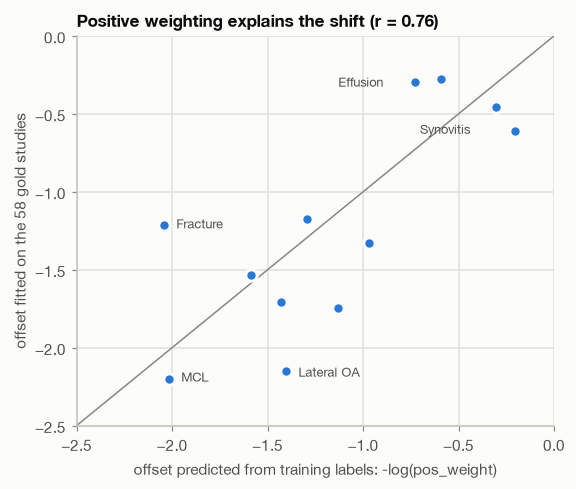

,training prevalence,gold prevalence,pos_weight,-log pos_weight,offset fitted on gold
ACL,0.19,0.41,4.17,-1.43,-1.71
MCL,0.12,0.16,7.51,-2.02,-2.20
Medial Meniscus,0.42,0.45,1.36,-0.31,-0.45
Lateral Meniscus,0.21,0.40,3.65,-1.30,-1.17
Medial OA,0.28,0.26,2.63,-0.97,-1.33
Lateral OA,0.20,0.19,4.07,-1.40,-2.15
PF OA,0.36,0.36,1.81,-0.59,-0.27
Effusion,0.33,0.60,2.07,-0.73,-0.30
Synovitis,0.45,0.47,1.23,-0.21,-0.61
Baker's,0.17,0.21,4.88,-1.59,-1.54


In [16]:
from scipy.stats import pearsonr

weights = pd.DataFrame({"training prevalence": S.mean(0), "gold prevalence": Y.mean(0), "pos_weight": pos_weight,
                        "-log pos_weight": -np.log(pos_weight), "offset fitted on gold": shifts}, index=rc.LAB)
r, p = pearsonr(weights["-log pos_weight"], weights["offset fitted on gold"])
print(f"shared slope after the weight correction: {slope_all:.2f}")
print(f"offset fitted on gold vs -log(pos_weight): Pearson r = {r:.2f} (p = {p:.3f})")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([-2.5, 0], [-2.5, 0], color=ps.MUTED, lw=1)
ax.scatter(weights["-log pos_weight"], weights["offset fitted on gold"], s=56, color=ps.BLUE, edgecolor=ps.SURFACE,
           linewidth=2, zorder=3)
for f, dx, dy in [("Fracture", 8, -2), ("Lateral OA", 8, -4), ("MCL", 8, -2), ("Effusion", -50, -3), ("Synovitis", -62, -2)]:
    ax.annotate(f, (weights.loc[f, "-log pos_weight"], weights.loc[f, "offset fitted on gold"]), xytext=(dx, dy),
                textcoords="offset points", fontsize=8.5, color=ps.INK_2)
ax.set_xlabel("offset predicted from training labels: -log(pos_weight)")
ax.set_ylabel("offset fitted on the 58 gold studies")
ax.set_xlim(-2.5, 0); ax.set_ylim(-2.5, 0)
ax.set_title(f"Positive weighting explains the shift (r = {r:.2f})")
fig.savefig(FIG / "phase5_pos_weight.png")
plt.show()
weights.round(2)

- **Subtracting log(pos_weight) alone does most of the repair.** ECE falls from 0.20 to 0.06 and Brier score from
  0.164 to 0.114, as good as the per-finding offsets fitted on the gold studies, without using any of them.
- **One shared slope then finishes the job** (1.44 after the weight correction), with ECE 0.04. Because it is a single
  parameter the leave-one-out jitter is tiny, and macro-AUC stays at 0.916.
- **The offsets fitted on gold follow -log(pos_weight)** with r = 0.76. The largest departure is fracture: the gold set
  has 31% fractures against 11% in training, and a set enriched for a finding needs a smaller downward shift for it.

So the calibration problem is fully accounted for by two lines of the training script (the positive weights and the
soft targets), and the first of the two fixes needs no labelled data at all.

## 7. Summary

| Question | Answer |
|---|---|
| Are errors spread or concentrated? | Concentrated: 25% of wrong pairs from 17 of 696 study-finding cells |
| Which studies are hard? | Nothing about site, scanner, field strength or preprocessing predicts it; multi-injury knees slightly (p = 0.05) |
| Which findings are confused? | Synovitis tracks effusion (scores 0.98, gold labels 0.40), inherited from training labels (0.88); OA compartments partly merged by the model itself |
| What are the worst 14 errors? | 1 clear miss, 4 label/report conflicts (model agrees with the report), 4 focal cartilage lesions labelled OA, 3 effusion scored as synovitis, 2 borderline |
| Are probabilities calibrated? | No: shifted up by positive weighting and compressed by soft targets (0.05-0.95). Subtracting log(pos_weight) from the training labels alone cuts calibration error from 0.20 to 0.06; adding one shared slope, to 0.04 |

Across Phases 2-5 the model looks better than its weakest numbers suggest. Its synovitis and PF OA scores are low
partly because those labels mix different things (fluid with synovium, focal injury with degeneration), and several of
its worst "errors" conflict with the report rather than with the image. The limits it does have are specific and
explainable: an effusion detector standing in for synovitis (because its training labels were one), an OA detector
that expects diffuse degeneration, and probabilities inflated by the loss weighting that a single subtraction
largely repairs.